In [1]:
# =============================================================================
# Notebook 04 — Retreino do modelo de Volume do PS (v2)
# Motivo: Cardiologia removida do fluxo do PS em 20/01/2026
# =============================================================================

import os
import sys
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
import joblib
import holidays

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

# Configuracao do novo modelo
NOVA_VERSAO = 'v2.0'
DATA_REMOCAO_CARDIO = pd.Timestamp('2026-01-21')  # Primeiro dia SEM cardiologia

print(f"Python: {sys.version.split()[0]}")
print(f"LightGBM: {lgb.__version__}")
print(f"Treinando {NOVA_VERSAO}")
print(f"Flag cardiologia removida a partir de: {DATA_REMOCAO_CARDIO.date()}")

Python: 3.11.9
LightGBM: 4.5.0
Treinando v2.0
Flag cardiologia removida a partir de: 2026-01-21


In [2]:
# =============================================================================
# Carrega historico e prepara serie diaria
# IMPORTANTE: exclui Cardiologia do total para que o modelo aprenda
# direto a "nova realidade" sem Cardiologia. A flag serve como sanity check
# para o modelo entender a descontinuidade.
# =============================================================================

df_raw = pd.read_parquet('../data/ml_ps_historico_chegadas.parquet')
print(f"Raw: {len(df_raw):,} atendimentos")

# Remove linhas de Cardiologia em TODO o historico
# (queremos que o modelo preveja o novo total, sem cardio)
df_sem_cardio = df_raw[df_raw['ds_clinica'] != 'Cardiologia'].copy()
print(f"Sem Cardiologia: {len(df_sem_cardio):,} atendimentos")
print(f"Removidos (cardio): {len(df_raw) - len(df_sem_cardio):,}")

# Agrupa por dia
serie = df_sem_cardio.groupby(df_sem_cardio['dt_entrada'].dt.date).size().reset_index(name='chegadas')
serie.columns = ['data', 'chegadas']
serie['data'] = pd.to_datetime(serie['data'])

# Remove o ultimo dia (incompleto)
ultimo_dia = serie['data'].max()
serie = serie[serie['data'] < ultimo_dia].copy()
serie = serie.set_index('data').asfreq('D')

print(f"\nSerie diaria sem Cardiologia:")
print(f"  {serie.index.min().date()} a {serie.index.max().date()}")
print(f"  {len(serie)} dias")
print(f"  Media: {serie['chegadas'].mean():.1f} chegadas/dia")

Raw: 236,864 atendimentos
Sem Cardiologia: 230,211 atendimentos
Removidos (cardio): 6,653

Serie diaria sem Cardiologia:
  2023-07-14 a 2026-04-08
  1000 dias
  Media: 230.2 chegadas/dia


In [3]:
clima = pd.read_parquet('../data/clima_ceilandia.parquet')
# Reindexa pra cobrir exatamente o mesmo range da serie
clima = clima.reindex(serie.index).ffill().bfill()
print(f"Clima alinhado: {len(clima)} dias")
print(f"Nulos em temp_media: {clima['temp_media'].isna().sum()}")

Clima alinhado: 1000 dias
Nulos em temp_media: 0


In [4]:
# =============================================================================
# Constroi features — mesmas do v1 + nova flag_clinica_removida
# =============================================================================

df = serie.copy()

# Calendario
df['ano'] = df.index.year
df['mes'] = df.index.month
df['dia_mes'] = df.index.day
df['dia_semana'] = df.index.dayofweek
df['dia_ano'] = df.index.dayofyear
df['semana_ano'] = df.index.isocalendar().week.astype(int).values
df['trimestre'] = df.index.quarter
df['is_segunda'] = (df['dia_semana'] == 0).astype(int)
df['is_fim_semana'] = (df['dia_semana'] >= 5).astype(int)
df['is_primeira_quinzena'] = (df['dia_mes'] <= 15).astype(int)
df['dia_semana_sin'] = np.sin(2 * np.pi * df['dia_semana'] / 7)
df['dia_semana_cos'] = np.cos(2 * np.pi * df['dia_semana'] / 7)
df['mes_sin'] = np.sin(2 * np.pi * df['mes'] / 12)
df['mes_cos'] = np.cos(2 * np.pi * df['mes'] / 12)

# Feriados
anos = list(range(df.index.year.min(), df.index.year.max() + 1))
feriados_br = holidays.Brazil(years=anos, subdiv='DF')
feriado_datas = set(feriados_br.keys())
df['is_feriado'] = df.index.to_series().apply(lambda d: d.date() in feriados_br).astype(int)
df['is_vespera_feriado'] = df.index.to_series().apply(lambda d: (d.date() + timedelta(days=1)) in feriado_datas).astype(int)
df['is_pos_feriado'] = df.index.to_series().apply(lambda d: (d.date() - timedelta(days=1)) in feriado_datas).astype(int)

# Eventos especiais
df['flag_surto_dengue_2024'] = ((df.index >= '2023-12-15') & (df.index <= '2024-04-15')).astype(int)
df['flag_clinica_removida'] = (df.index >= DATA_REMOCAO_CARDIO).astype(int)   # ⭐ NOVA

# Lags
df['lag_1d'] = df['chegadas'].shift(1)
df['lag_2d'] = df['chegadas'].shift(2)
df['lag_7d'] = df['chegadas'].shift(7)
df['lag_14d'] = df['chegadas'].shift(14)
df['media_movel_7d'] = df['chegadas'].shift(1).rolling(7).mean()
df['media_movel_28d'] = df['chegadas'].shift(1).rolling(28).mean()
df['std_movel_7d'] = df['chegadas'].shift(1).rolling(7).std()

# Clima
df = df.join(clima, how='left')

print(f"Features construidas. Shape: {df.shape}")
print(f"Dias com flag_clinica_removida=1: {df['flag_clinica_removida'].sum()}")

Features construidas. Shape: (1000, 35)
Dias com flag_clinica_removida=1: 78


In [5]:
# =============================================================================
# Features e split
# =============================================================================

FEATURES = [
    'ano', 'mes', 'dia_mes', 'dia_semana', 'dia_ano', 'semana_ano', 'trimestre',
    'is_segunda', 'is_fim_semana', 'is_primeira_quinzena',
    'dia_semana_sin', 'dia_semana_cos', 'mes_sin', 'mes_cos',
    'is_feriado', 'is_vespera_feriado', 'is_pos_feriado',
    'flag_surto_dengue_2024',
    'flag_clinica_removida',   # ⭐ NOVA
    'temp_max', 'temp_min', 'temp_media',
    'precipitacao_mm', 'chuva_mm', 'horas_chuva',
    'umidade_media', 'vento_max',
    'lag_1d', 'lag_2d', 'lag_7d', 'lag_14d',
    'media_movel_7d', 'media_movel_28d', 'std_movel_7d',
]

df_model = df.dropna(subset=FEATURES).copy()

CORTE_TREINO    = '2026-03-20'
CORTE_VALIDACAO = '2026-04-03'

df_treino = df_model[df_model.index <= CORTE_TREINO]
df_valid  = df_model[(df_model.index > CORTE_TREINO) & (df_model.index <= CORTE_VALIDACAO)]
df_teste  = df_model[df_model.index > CORTE_VALIDACAO]

X_treino, y_treino = df_treino[FEATURES], df_treino['chegadas']
X_valid,  y_valid  = df_valid[FEATURES],  df_valid['chegadas']
X_teste,  y_teste  = df_teste[FEATURES],  df_teste['chegadas']

print(f"Treino:     {len(df_treino):4d} dias | {df_treino.index.min().date()} → {df_treino.index.max().date()}")
print(f"Validacao:  {len(df_valid):4d} dias | {df_valid.index.min().date()} → {df_valid.index.max().date()}")
print(f"Teste:      {len(df_teste):4d} dias | {df_teste.index.min().date()} → {df_teste.index.max().date()}")

# Treino
params = {
    'objective': 'regression', 'metric': 'mae', 'boosting_type': 'gbdt',
    'num_leaves': 31, 'learning_rate': 0.05,
    'feature_fraction': 0.8, 'bagging_fraction': 0.8, 'bagging_freq': 5,
    'min_child_samples': 10, 'verbose': -1, 'seed': 42, 'n_jobs': -1,
}

model = lgb.train(
    params,
    lgb.Dataset(X_treino, label=y_treino),
    num_boost_round=2000,
    valid_sets=[lgb.Dataset(X_treino, label=y_treino), lgb.Dataset(X_valid, label=y_valid)],
    valid_names=['treino', 'validacao'],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)],
)

print(f"\n✅ Arvores: {model.best_iteration}  |  MAE validacao: {model.best_score['validacao']['l1']:.2f}")

Treino:      953 dias | 2023-08-11 → 2026-03-20
Validacao:    14 dias | 2026-03-21 → 2026-04-03
Teste:         5 dias | 2026-04-04 → 2026-04-08
Training until validation scores don't improve for 50 rounds
[100]	treino's l1: 8.2911	validacao's l1: 9.68548
Early stopping, best iteration is:
[105]	treino's l1: 7.99183	validacao's l1: 9.57719

✅ Arvores: 105  |  MAE validacao: 9.58


COMPARACAO v1 vs v2
Metrica              v1              v2              Delta
-----------------------------------------------------------------
MAE teste            14.12           22.77           +8.65
MAPE teste           6.32           % 9.05          % +2.73%
RMSE teste           15.95           25.10          


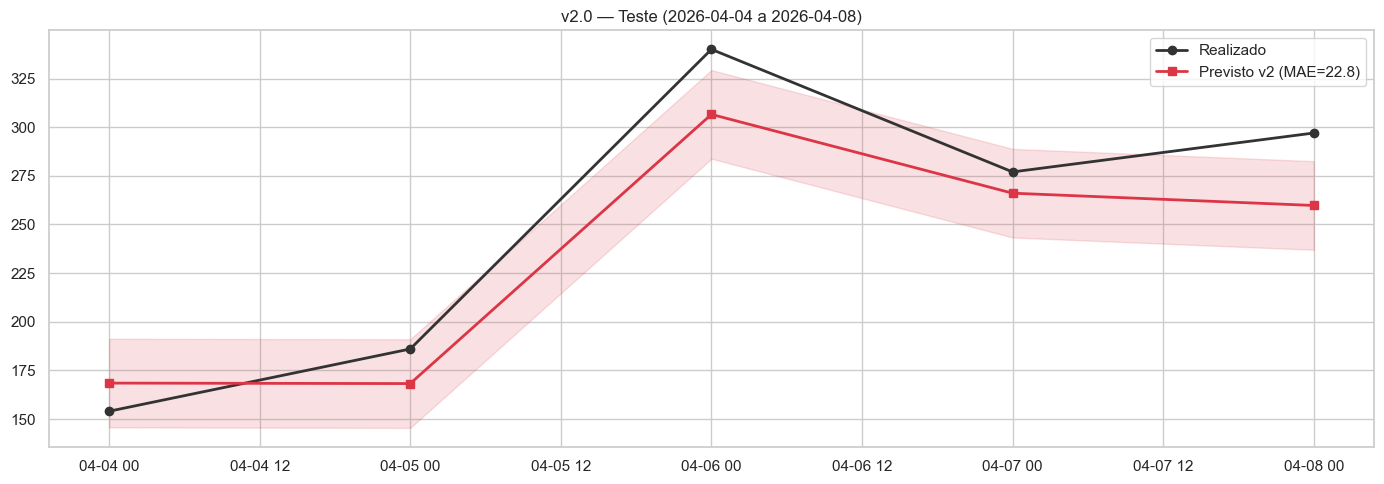


TOP 10 FEATURES (v2):
  lag_7d                        45.1%
  lag_14d                       19.1%
  dia_semana                     7.9%
  lag_1d                         5.6%
  media_movel_7d                 4.9%
  lag_2d                         2.1%
  dia_ano                        1.9%
  is_feriado                     1.6%
  media_movel_28d                1.2%
  std_movel_7d                   1.1%


In [6]:
pred_teste = model.predict(X_teste, num_iteration=model.best_iteration)
mae_teste = mean_absolute_error(y_teste, pred_teste)
rmse_teste = np.sqrt(mean_squared_error(y_teste, pred_teste))
mape_teste = np.mean(np.abs((y_teste - pred_teste) / y_teste)) * 100

# Carrega metricas do v1 pra comparar
with open('../models/ps_volume_v1_meta.json') as f:
    meta_v1 = json.load(f)

print("="*70)
print("COMPARACAO v1 vs v2")
print("="*70)
print(f"{'Metrica':<20} {'v1':<15} {'v2':<15} {'Delta'}")
print(f"{'-'*65}")
print(f"{'MAE teste':<20} {meta_v1['metricas']['mae_teste']:<15.2f} {mae_teste:<15.2f} {mae_teste - meta_v1['metricas']['mae_teste']:+.2f}")
print(f"{'MAPE teste':<20} {meta_v1['metricas']['mape_teste']:<15.2f}% {mape_teste:<14.2f}% {mape_teste - meta_v1['metricas']['mape_teste']:+.2f}%")
print(f"{'RMSE teste':<20} {meta_v1['metricas']['rmse_teste']:<15.2f} {rmse_teste:<15.2f}")

# Grafico comparativo
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_teste.index, y_teste, 'o-', color='#333', label='Realizado', linewidth=2)
ax.plot(df_teste.index, pred_teste, 's-', color='#dc3545', label=f'Previsto v2 (MAE={mae_teste:.1f})', linewidth=2)
ax.fill_between(df_teste.index, pred_teste - mae_teste, pred_teste + mae_teste, alpha=0.15, color='#dc3545')
ax.set_title(f'v2.0 — Teste ({df_teste.index.min().date()} a {df_teste.index.max().date()})')
ax.legend()
plt.tight_layout()
plt.show()

# Feature importance com destaque pra nova flag
importance = pd.DataFrame({
    'feature': FEATURES,
    'importance': model.feature_importance(importance_type='gain'),
}).sort_values('importance', ascending=True)

total = importance['importance'].sum()
print("\nTOP 10 FEATURES (v2):")
for _, row in importance.tail(10).iloc[::-1].iterrows():
    destaque = " ⭐" if row['feature'] == 'flag_clinica_removida' else ""
    print(f"  {row['feature']:<28} {row['importance']/total*100:5.1f}%{destaque}")

In [7]:
# =============================================================================
# Serializa v2 e PREPARA update do features.py de producao
# =============================================================================

# Salva .pkl e metadata
joblib.dump(model, '../models/ps_volume_v2.pkl')

meta_v2 = {
    'nome': 'ps_volume_v2',
    'versao': NOVA_VERSAO,
    'descricao': 'v2: inclui flag_clinica_removida (Cardiologia removida em 20/01/2026)',
    'data_treino': datetime.now().strftime('%Y-%m-%d %H:%M'),
    'periodo_treino': f"{df_treino.index.min().date()} a {df_treino.index.max().date()}",
    'periodo_validacao': f"{df_valid.index.min().date()} a {df_valid.index.max().date()}",
    'periodo_teste': f"{df_teste.index.min().date()} a {df_teste.index.max().date()}",
    'num_features': len(FEATURES),
    'features': FEATURES,
    'target': 'chegadas',
    'metricas': {
        'mae_teste': round(mae_teste, 2),
        'mape_teste': round(mape_teste, 2),
        'rmse_teste': round(rmse_teste, 2),
    },
    'hiperparametros': params,
    'num_arvores': model.best_iteration,
    'modelo': 'LightGBM',
    'mudanca_versao': 'Adicionada flag_clinica_removida a partir de 2026-01-21 (remocao de Cardiologia)',
}

with open('../models/ps_volume_v2_meta.json', 'w', encoding='utf-8') as f:
    json.dump(meta_v2, f, ensure_ascii=False, indent=2)

print("✅ Modelo v2 salvo em ../models/ps_volume_v2.pkl")
print("✅ Metadata salvo em ../models/ps_volume_v2_meta.json")
print(f"\nMAE teste v2: {mae_teste:.2f}  (v1 era {meta_v1['metricas']['mae_teste']})")

✅ Modelo v2 salvo em ../models/ps_volume_v2.pkl
✅ Metadata salvo em ../models/ps_volume_v2_meta.json

MAE teste v2: 22.77  (v1 era 14.12)
